In [ ]:
# Group Members: Mauricio Ferreyra-Ruiz, Priyanshu Rathor
# Dataset link: https://www.kaggle.com/datasets/sahilislam007/spotify-user-behavior-and-pattern

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)

In [ ]:
# Loading the Dataset

df = pd.read_csv("spotify_user_behavior_realistic_50000_rows.csv")
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [ ]:
# Feature Engineering

# Dropping features that may be irrelevant for this dataset
df_model = df.drop(columns=["user_id", "signup_date"]).copy()

# Label Encoding
# Corrected: 'include' takes a list
cat_cols = df_model.select_dtypes(include=['object', 'string']).columns.tolist()

# Ensure 'subscription_status' is not processed in the general loop
if "subscription_status" in cat_cols:
    cat_cols.remove("subscription_status")

le_features = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_features[col] = le
    mapping = {index: label for index, label in enumerate(le.classes_)}
    print(f" {col}: {mapping}")

# Encoding the target feature
le_target = LabelEncoder() # Storing for later use in classification_report
df_model["subscription_status"] = le_target.fit_transform(df_model["subscription_status"])

# Separating the Target feature from the Dataset
# X and y should be derived from df_model, not the original df
X = df_model.drop(columns=["subscription_status"])
y = df_model["subscription_status"]

 country: {0: 'Australia', 1: 'Brazil', 2: 'Canada', 3: 'France', 4: 'Germany', 5: 'India', 6: 'Indonesia', 7: 'Italy', 8: 'Mexico', 9: 'Spain', 10: 'UK', 11: 'USA'}
 subscription_type: {0: 'Free', 1: 'Premium Duo', 2: 'Premium Family', 3: 'Premium Individual', 4: 'Student'}
 ad_interaction: {0: 'No', 1: 'Yes'}
 ad_conversion_to_subscription: {0: 'No', 1: 'Yes'}
 favorite_genre: {0: 'Bollywood', 1: 'Classical', 2: 'Country', 3: 'Electronic', 4: 'Hip-Hop', 5: 'Indie', 6: 'Jazz', 7: 'K-Pop', 8: 'Latin', 9: 'Pop', 10: 'R&B', 11: 'Rock'}
 most_liked_feature: {0: 'AI DJ', 1: 'Daily Mix', 2: 'Discover Weekly', 3: 'Lyrics', 4: 'Offline Mode', 5: 'Playlists', 6: 'Podcasts', 7: 'Radio'}
 desired_future_feature: {0: 'Better AI Recommendations', 1: 'Concert Alerts', 2: 'HiFi Audio', 3: 'Lyrics Translation', 4: 'Mood-based Auto Playlists', 5: 'Social Listening'}
 primary_device: {0: 'Car System', 1: 'Desktop', 2: 'Mobile', 3: 'Smart Speaker', 4: 'Tablet'}


In [ ]:
# Training and Testing the data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling the Features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Creating and Training the KNN Model with K value = 5

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Making the predicitions

y_pred = knn.predict(X_test_scaled)

Overall Accuracy (k=5): 92.12%

Classification Report:
              precision    recall  f1-score   support

      Active       0.97      0.94      0.95      8482
    Inactive       0.70      0.84      0.76      1518

    accuracy                           0.92     10000
   macro avg       0.84      0.89      0.86     10000
weighted avg       0.93      0.92      0.92     10000



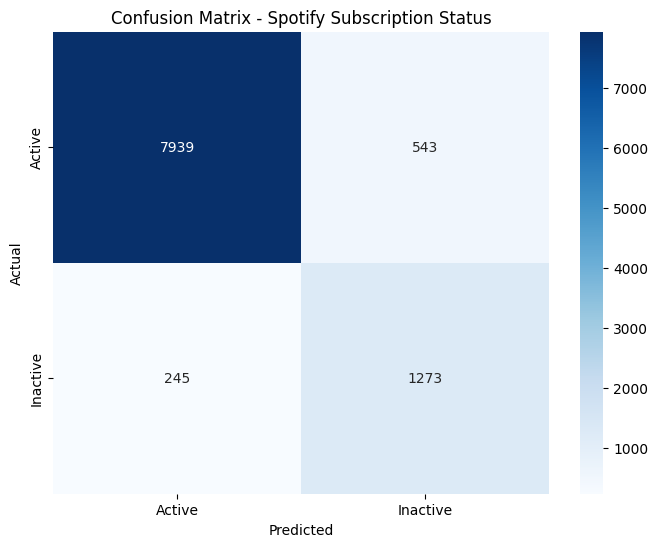

In [ ]:
# Getting the overall accuracy

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy (k=5): {accuracy:.2%}")
print()

# Classification Report

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Creating the Confusion Matrix

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_,
)

plt.title("Confusion Matrix - Spotify Subscription Status")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Finding the best K value to use in this dataset

k_values = range(1,21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"Best K value: {best_k}")
print(f"Best Accuracy: {best_accuracy:.2%}")


Best K value: 19
Best Accuracy: 93.33%


In [ ]:
# Retraining the model with the best K value that was just found

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

y_pred_best = knn_best.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"Accuracy with Best K value: {accuracy_best:.2%}")
print("Classification Report with Best K value:")
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))

Accuracy with Best K value: 93.33%
Classification Report with Best K value:
              precision    recall  f1-score   support

      Active       1.00      0.93      0.96      8482
    Inactive       0.70      0.97      0.82      1518

    accuracy                           0.93     10000
   macro avg       0.85      0.95      0.89     10000
weighted avg       0.95      0.93      0.94     10000



In [ ]:
# Predicitng a New Spotify User with the new Model

# Encoded Reference Guide (Legend)
#   country: Australia=0, Brazil=1, Canada=2, France=3,
#            Germany=4, India=5, Indonesia=6, Italy=7,
#            Mexico=8, UK=9, USA=10
#   subscription_type: Free=0, Premium Duo=1, Premium Family=2,
#                      Premium Individual=3, Student=4
#   ad_interaction: No=0, Yes=1
#   ad_conversion_to_subscription: No=0, Yes=1
#   favorite_genre: Bollywood=0, Classical=1, Country=2,
#                   Electronic=3, Hip-Hop=4, Indie=5,
#                   Jazz=6, K-Pop=7, Latin=8, Pop=9, R&B=10, Rock=11
#   most_liked_feature: AI DJ=0, Daily Mix=1, Discover Weekly=2,
#                       Lyrics=3, Offline Mode=4, Playlists=5,
#                       Podcasts=6, Radio=7
#   desired_future_feature: Better AI Recommendations=0, Concert Alerts=1,
#                           HiFi Audio=2, Lyrics Translation=3,
#                           Mood-based Auto Playlists=4, Social Listening=5
#   primary_device: Car System=0, Desktop=1, Mobile=2,
#                   Smart Speaker=3, Tablet=4

new_user = pd.DataFrame({
    "country": [3],
    "age": [28],
    "subscription_type": [0],
    "months_inactive": [4],
    "inactive_3_months_flag": [1], # Added: Based on months_inactive, if >3 set to 1, else 0
    "ad_interaction": [1],
    "ad_conversion_to_subscription": [0], # Renamed from 'ad_conversion'
    "music_suggestion_rating_1_to_5": [2],
    "avg_listening_hours_per_week": [3.5], # Added: Example value
    "favorite_genre": [8],
    "most_liked_feature": [7],
    "desired_future_feature": [1],
    "primary_device": [2],
    "playlists_created": [2],
    "avg_skips_per_day": [12]
})

print("Please enter the following information:")
print(new_user.to_string(index=False))
print()

# Scaling the new user
# Ensure the columns are in the same order as X_train
new_user_scaled = scaler.transform(new_user[X_train.columns])

# Making the Prediction

prediction = knn_best.predict(new_user_scaled)
probabilities = knn_best.predict_proba(new_user_scaled)

print(f"Predicted subscription status: {le_target.inverse_transform(prediction)[0]}")
print()
print("Confidence scores:")
for class_name, prob in zip(le_target.classes_, probabilities[0]): # Corrected 'probability' to 'probabilities'
    bar = "█" * int(prob * 30)
    print(f"   {class_name:10s} {prob:6.1%}  {bar}")

Please enter the following information:
 country  age  subscription_type  months_inactive  inactive_3_months_flag  ad_interaction  ad_conversion_to_subscription  music_suggestion_rating_1_to_5  avg_listening_hours_per_week  favorite_genre  most_liked_feature  desired_future_feature  primary_device  playlists_created  avg_skips_per_day
       3   28                  0                4                       1               1                              0                               2                           3.5               8                   7                       1               2                  2                 12

Predicted subscription status: Inactive

Confidence scores:
   Active      36.8%  ███████████
   Inactive    63.2%  ██████████████████


# Executive Summary

For this Spotify user behavior dataset we made a K-Nearest Neighbor algorithm to be able to predict if a user listed is active or inactive on Spotify. This Dataset was created synthetically according to the Kaggle creator but provided features such as age, country, subscription type, listening hours, genre preference, device usage ect. which helped develop a realistic environment with user responses.

After testing and determining which K value would be the best K value to use in regard to this dataset we noticed that users that had lower listening hours, and fewer playlists created were more than likely on the "Inactive" classification of the Spotify Behavior.

By using this algorithm and model, the organization can run predictions on if their user is close to becoming fully inactive and try to provide some incentives to try and keep their users from continuing using the app like offering discounts to some of their memborships or notifications saying that they miss them like how other apps do it.

2ND DATASET

DATASET: https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

print("=" * 60)
print("   KNN Example: Apple Quality Classification")
print("=" * 60)
print()

Saving apple_quality.csv to apple_quality (1).csv
   KNN Example: Apple Quality Classification



In [ ]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("STEP 2: Dataset Overview")
print("-" * 40)
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print()


STEP 2: Dataset Overview
----------------------------------------
Shape: (4001, 9)

First 5 rows:
   A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
0   0.0 -3.970049 -2.512336   5.346330    -1.012009   1.844900  0.329840   
1   1.0 -1.195217 -2.839257   3.664059     1.588232   0.853286  0.867530   
2   2.0 -0.292024 -1.351282  -1.738429    -0.342616   2.838636 -0.038033   
3   3.0 -0.657196 -2.271627   1.324874    -0.097875   3.637970 -3.413761   
4   4.0  1.364217 -1.296612  -0.384658    -0.553006   3.030874 -1.303849   

        Acidity Quality  
0  -0.491590483    good  
1  -0.722809367    good  
2   2.621636473     bad  
3   0.790723217    good  
4   0.501984036    good  



In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

In [ ]:
# Remove unwanted column
if 'A_id' in df.columns:
    df = df.drop(columns=['A_id'])

In [ ]:
# Convert Quality to numeric
df['Quality'] = df['Quality'].map({'good': 1, 'bad': 0})


In [ ]:
#this one was tricky other commands was not working to remove last row
#this removes any row that contains the text is not real data or like "created by"
df = df[~df.astype(str).apply(lambda x: x.str.contains("Created_by", na=False)).any(axis=1)]
df = df.reset_index(drop=True)

In [ ]:
print("STEP 3: Preparing Data")
print("-" * 40)


STEP 3: Preparing Data
----------------------------------------


In [ ]:
#remove this because that is what we want to predict
X = df.drop('Quality', axis=1)
y = df['Quality']

In [ ]:
#its imporatant to not get error
#converts vales to numbers
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

In [ ]:
#just to make sure no empty values
X = X.fillna(X.mean())

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print()

Features shape: (4000, 7)
Labels shape: (4000,)



In [ ]:
#split the dataset for taining and testing in 80:20.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print()


Training samples: 3200
Testing samples: 800



In [ ]:
#this is also impotant so the data train and teat at same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
print("Features scaled using StandardScaler")
print()


Features scaled using StandardScaler



In [ ]:
print("STEP 4: Training KNN Model")
print("-" * 40)
#train the KNN model using the training data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("Model trained with K=5")
print()


STEP 4: Training KNN Model
----------------------------------------
Model trained with K=5



In [ ]:
#use trained model to predict the apple quality for test
y_pred = knn.predict(X_test_scaled)

print("Predictions completed")
print()


Predictions completed



In [ ]:
print("STEP 6: Model Evaluation")
print("-" * 40)
#shows accuracy as a percentage
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print()
#shows model performance
print("Classification Report:")
print(classification_report(y_test, y_pred))
#this will sho how apples are classified
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()


STEP 6: Model Evaluation
----------------------------------------
Accuracy: 90.25%

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.90      0.90       401
         1.0       0.90      0.91      0.90       399

    accuracy                           0.90       800
   macro avg       0.90      0.90      0.90       800
weighted avg       0.90      0.90      0.90       800

Confusion Matrix:
[[360  41]
 [ 37 362]]



In [ ]:
#this is important for logical output, gives idea to user
#shows its range, ask the user to enter value, converts the value to float and saves it in list
print("STEP 7: Feature Ranges")
print("-" * 40)

feature_ranges = {}

for col in X.columns:
    min_val = X[col].min()
    max_val = X[col].max()
    feature_ranges[col] = (min_val, max_val)
    print(f"{col}: {min_val:.2f} to {max_val:.2f}")

print()


STEP 7: Feature Ranges
----------------------------------------
Size: -7.15 to 6.41
Weight: -7.15 to 5.79
Sweetness: -6.89 to 6.37
Crunchiness: -6.06 to 7.62
Juiciness: -5.96 to 7.36
Ripeness: -5.86 to 7.24
Acidity: -7.01 to 7.40



In [ ]:
def predict_apple():
    while True:
        try:
            print("\nEnter apple values in this order:")
            print(list(X.columns))

            values = []

            for col in X.columns:
                min_val, max_val = feature_ranges[col]
                val = float(input(f"{col} ({min_val:.2f} - {max_val:.2f}): "))
                values.append(val)
#create a new row dataframe from user input
            new_data = pd.DataFrame([values], columns=X.columns)

            #scale input
            #scale the new input using the same scaler from training.
            new_scaled = scaler.transform(new_data)

            # Predict
            prediction = knn.predict(new_scaled)[0]

            if prediction == 1:
                print("Prediction: Good Apple")
            else:
                print("Prediction: Bad Apple")
#ask users if they want another prediction
            again = input("Predict another apple? (yes/no): ")
            if again.lower() != 'yes':
                break
#if somthing wrong print error
        except Exception as e:
            print("Error:", e)

predict_apple()

print()
print("=" * 60)
print("   DONE! Apple Quality Classification Complete")
print("=" * 60)


Enter apple values in this order:
['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness', 'Acidity']
Prediction: Bad Apple

Enter apple values in this order:
['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness', 'Acidity']
Prediction: Good Apple


# Executive Summary

We understand the K-Nearest Neighbors(KNN) algorithm to predict apples as good or bad. Firstly, we loaded the apple dataset and cleaned it by removing extra spaces, unwanted columns and bad rows then we changed the quality labels into numbers so the model could understand them and after that separated the input features and the target and then fixed missing values and split the data into training and testing parts and then we scaled the feature values because KNN uses distance and scaling makes the comparison fair. 

Then we trained the model and made predictions on the test data and checked the results using accuracy, classification report and confusion matrix and then we created a prediction function where the user can enter apple values and the program predicts if the apple is good or bad. 

This is helpful in real life because it can be used for quality checking in farming, food companies and stores.